# 按分数分三组

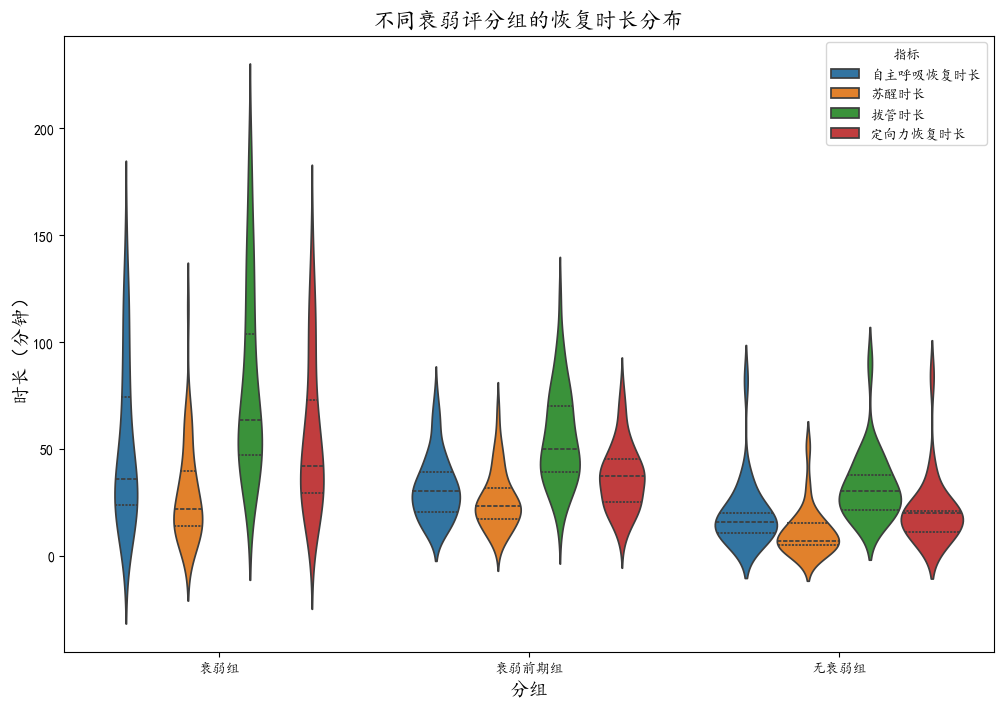

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False
# 读取CSV文件
data = pd.read_csv('复苏时长.csv')

# 创建DataFrame
df = pd.DataFrame(data)

# 定义衰弱评分分组
def get_group(score):
    if score == 0:
        return '无衰弱组'
    elif 1 <= score <= 2:
        return '衰弱前期组'
    elif 3 <= score <= 4:
        return '衰弱组'

# 添加分组列
df['分组'] = df['衰弱评分'].apply(get_group)

# 将数据转换为长格式
df_long = df.melt(id_vars=['分组'], 
                  value_vars=['自主呼吸恢复时长', '苏醒时长', '拔管时长', '定向力恢复时长'],
                  var_name='指标', 
                  value_name='时长（分钟）')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 绘制小提琴图
plt.figure(figsize=(12, 8))
sns.violinplot(x='分组', y='时长（分钟）', hue='指标', data=df_long, split=False, inner='quartile')

# 设置标题和标签
plt.title('不同衰弱评分组的恢复时长分布', fontsize=16)
plt.xlabel('分组', fontsize=14)
plt.ylabel('时长（分钟）', fontsize=14)

# 显示图例
plt.legend(title='指标', loc='upper right')
plt.savefig('按score分组.png', dpi=400, bbox_inches='tight')
# 显示图形
plt.show()

In [ ]:
conda install statsmodels
conda install scipy

In [ ]:
conda install -c conda-forge scikit-posthocs

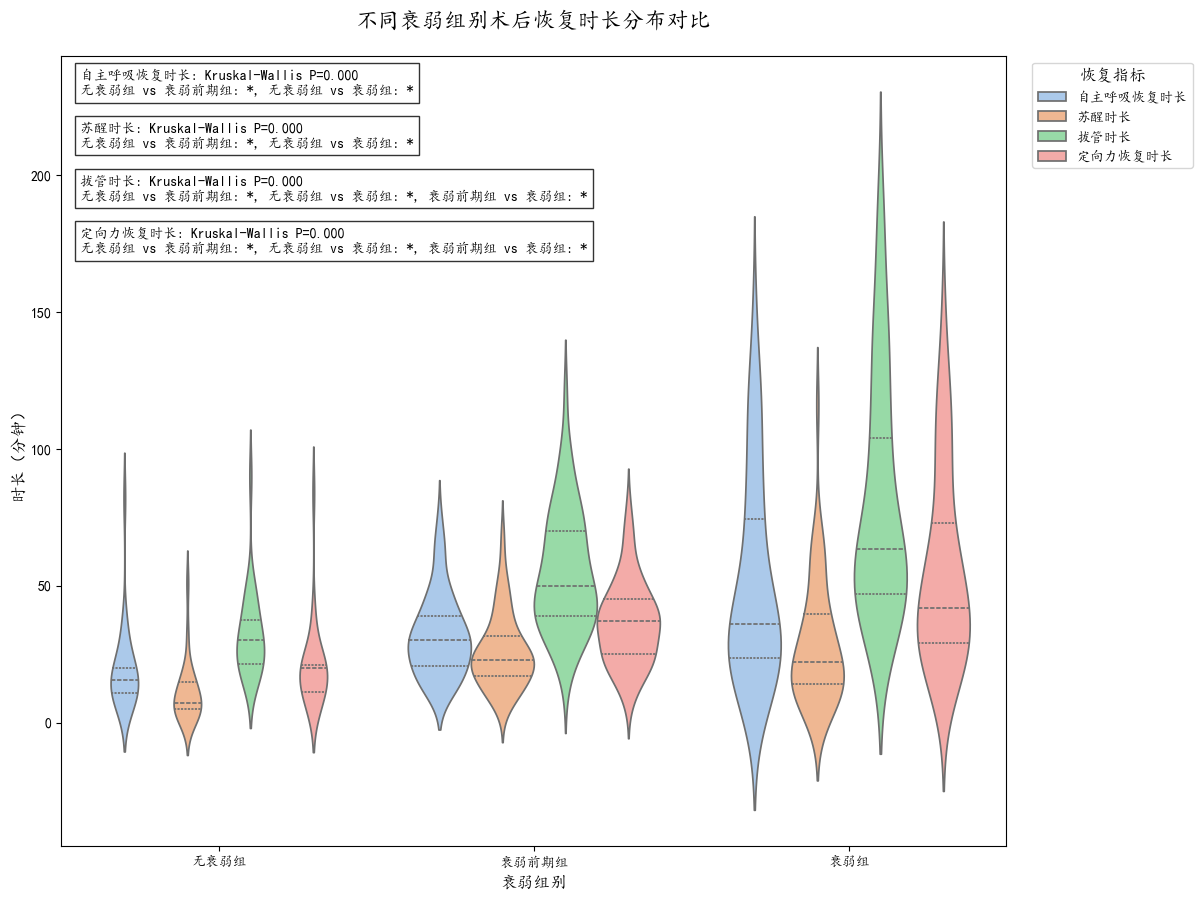

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn  # 确保已安装scikit-posthocs
import numpy as np
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# 读取数据
df = pd.read_csv('复苏时长.csv')

# 定义衰弱分组
bins = [0, 1, 3, 5]
labels = ['无衰弱组', '衰弱前期组', '衰弱组']
df['衰弱组别'] = pd.cut(df['衰弱评分'], bins=bins, labels=labels, right=False)

# 转换为长格式
melted_df = df.melt(
    id_vars='衰弱组别',
    value_vars=['自主呼吸恢复时长', '苏醒时长', '拔管时长', '定向力恢复时长'],
    var_name='恢复指标',
    value_name='时长'
)

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 创建画布（增加高度以容纳更多文本）
plt.figure(figsize=(14, 10))  # 增大高度

# 绘制小提琴图
ax = sns.violinplot(
    x='衰弱组别',
    y='时长',
    hue='恢复指标',
    data=melted_df,
    split=False,
    inner='quartile',
    palette='pastel',
    density_norm='count'
)

# 添加标题和标签
plt.title('不同衰弱组别术后恢复时长分布对比', fontsize=16, pad=20)
plt.xlabel('衰弱组别', fontsize=12)
plt.ylabel('时长（分钟）', fontsize=12)

# 调整图例位置
plt.legend(
    title='恢复指标',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    title_fontsize=12
)

# 执行统计检验并标注P值
unique_metrics = melted_df['恢复指标'].unique()

# 为每个指标分配垂直位置（避免重叠）
y_positions = np.linspace(0.95, 0.75, len(unique_metrics))  # 从顶部95%到75%均匀分布

for i, metric in enumerate(unique_metrics):
    subset = melted_df[melted_df['恢复指标'] == metric]
    
    # Kruskal-Wallis检验
    groups = subset.groupby('衰弱组别', observed=True)['时长'].apply(list)
    h_stat, p_value = kruskal(*groups.values)
    
    # 事后检验（Dunn检验）
    dunn_results = posthoc_dunn(subset, val_col='时长', group_col='衰弱组别')
    
    # 获取显著性标记
    sig_marks = []
    for idx1, group1 in enumerate(dunn_results.index):
        for idx2, group2 in enumerate(dunn_results.columns):
            if idx1 < idx2 and dunn_results.iloc[idx1, idx2] < 0.05:
                sig_marks.append(f'{group1} vs {group2}: *')
    
    # 添加P值标注（使用轴坐标系）
    text_str = (
        f'{metric}: Kruskal-Wallis P={p_value:.3f}\n'
        + ', '.join(sig_marks)
    )
    plt.text(
        x=0.02,
        y=y_positions[i],  # 使用预计算的垂直位置
        s=text_str,
        fontsize=10,
        transform=ax.transAxes,  # 使用轴坐标系
        bbox=dict(facecolor='white', alpha=0.8)
    )

# 手动调整布局（替代tight_layout）
plt.subplots_adjust(right=0.8, top=0.9)  # 为图例腾出空间
plt.show()